In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



In [14]:
dataset = pd.read_csv('Housing.csv')
dataset.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [15]:
label_encoder = LabelEncoder()
dataset['mainroad_code'] = label_encoder.fit_transform(dataset['mainroad'])
dataset['guestroom_code'] = label_encoder.fit_transform(dataset['guestroom'])
dataset['basement_code'] = label_encoder.fit_transform(dataset['basement']) 
dataset['hotwaterheating_code'] = label_encoder.fit_transform(dataset['hotwaterheating'])
dataset['airconditioning_code'] = label_encoder.fit_transform(dataset['airconditioning'])
dataset['prefarea_code'] = label_encoder.fit_transform(dataset['prefarea'])
dataset['furnishingstatus_code'] = label_encoder.fit_transform(dataset['furnishingstatus'])

dataset.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,mainroad_code,guestroom_code,basement_code,hotwaterheating_code,airconditioning_code,prefarea_code,furnishingstatus_code
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished,1,0,1,0,0,0,2
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished,1,0,0,0,0,0,2
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished,0,0,0,0,0,0,0
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished,1,0,0,0,0,0,2


Numeric columns with outliers (count of rows with at least one outlier in that column):
stories      41
price        15
area         12
bedrooms     12
parking      12
bathrooms     1
dtype: int64

Total rows with any numeric outlier: 82
Rows remaining after dropping outliers: 463

Columns detected with outliers: ['stories', 'price', 'area', 'bedrooms', 'parking', 'bathrooms']


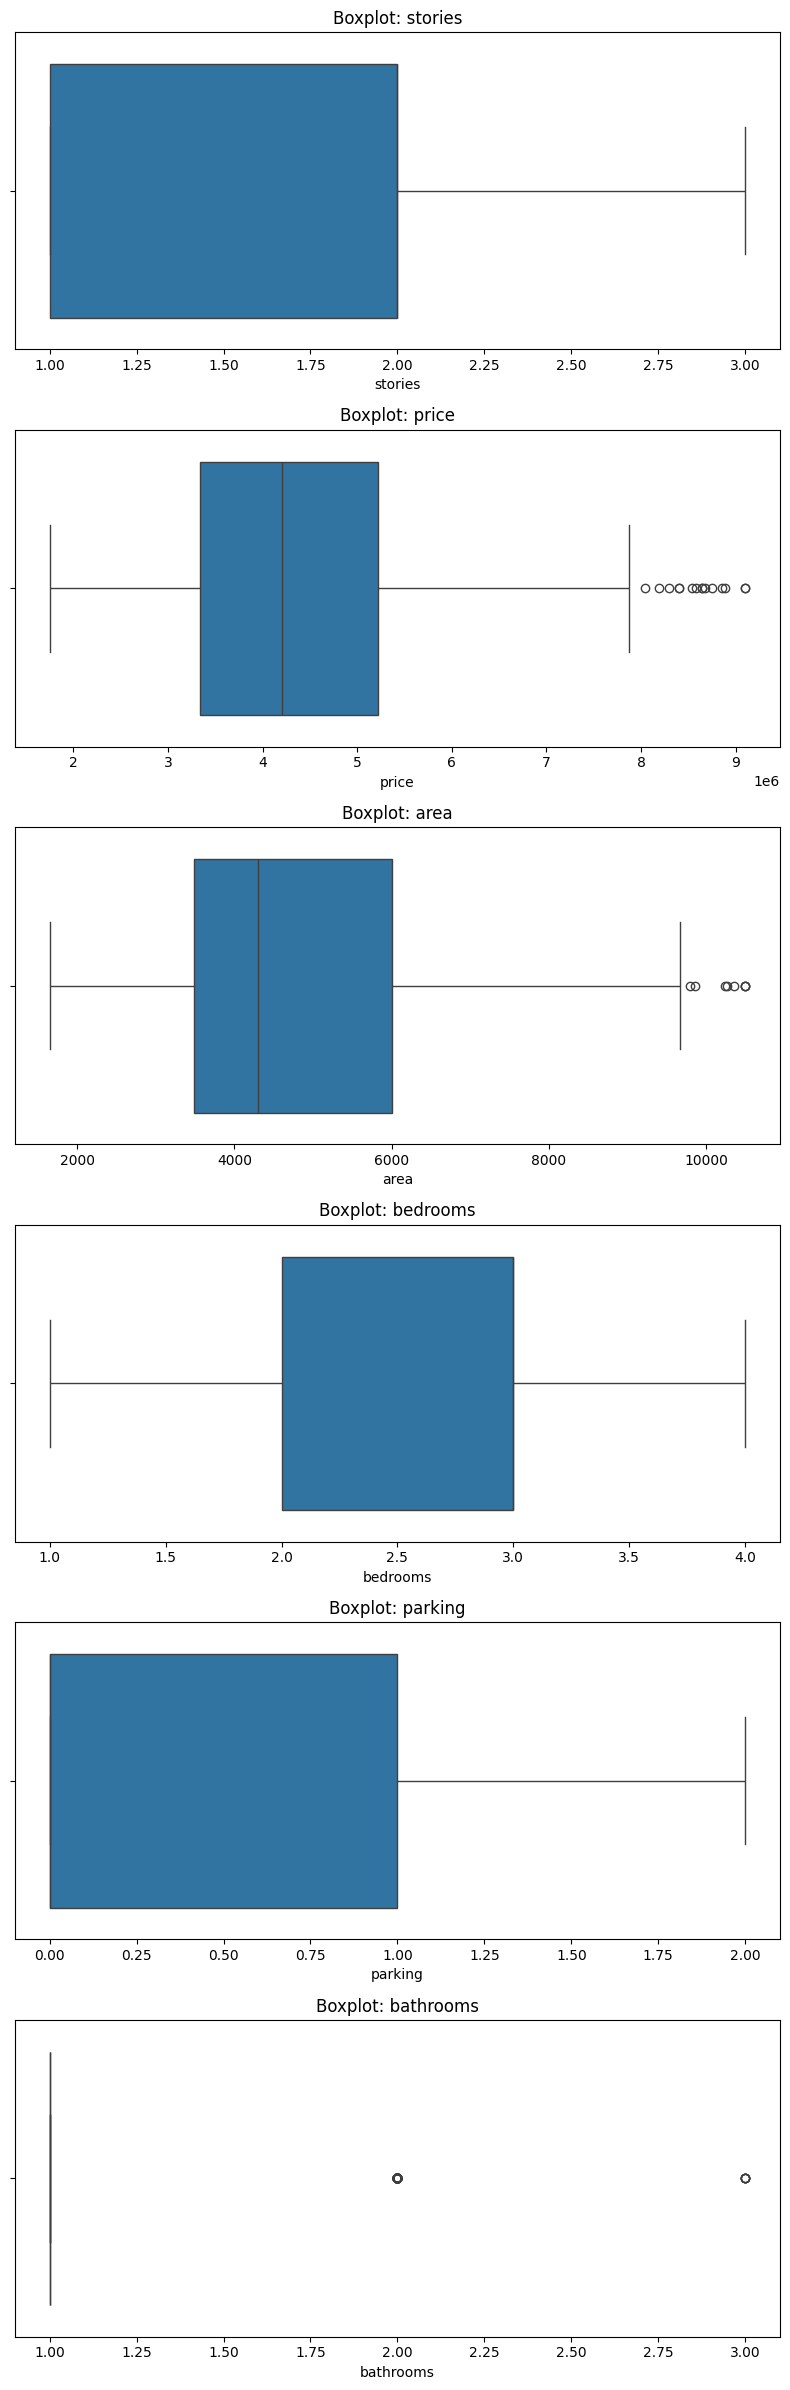

In [16]:
# Detect outliers in numeric columns using the IQR method
# Only use numeric columns that are not encoded (we exclude the label-encoded *_code columns).
numeric_cols = dataset.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if not c.endswith("_code")]

Q1 = dataset[numeric_cols].quantile(0.25)
Q3 = dataset[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (dataset[numeric_cols] < (Q1 - 1.5 * IQR)) | (dataset[numeric_cols] > (Q3 + 1.5 * IQR))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print("Numeric columns with outliers (count of rows with at least one outlier in that column):")
print(outlier_counts[outlier_counts > 0])

# Show a small sample of rows that have any outlier
has_outlier = outlier_mask.any(axis=1)
print(f"\nTotal rows with any numeric outlier: {has_outlier.sum()}")
dataset.loc[has_outlier].head()

# Remove rows with any numeric outliers from the dataset
dataset = dataset.loc[~has_outlier].reset_index(drop=True)
print(f"Rows remaining after dropping outliers: {dataset.shape[0]}")

# Visualize the numeric columns that have outliers
import matplotlib.pyplot as plt
import seaborn as sns

cols_with_outliers = outlier_counts[outlier_counts > 0].index.tolist()
print(f"\nColumns detected with outliers: {cols_with_outliers}")

if cols_with_outliers:
    # Plot a boxplot for each column with outliers
    fig, axes = plt.subplots(nrows=len(cols_with_outliers), ncols=1, figsize=(8, 4 * len(cols_with_outliers)))
    if len(cols_with_outliers) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_with_outliers):
        sns.boxplot(x=dataset[col], ax=ax)
        ax.set_title(f"Boxplot: {col}")
        ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns with outliers to visualize.")

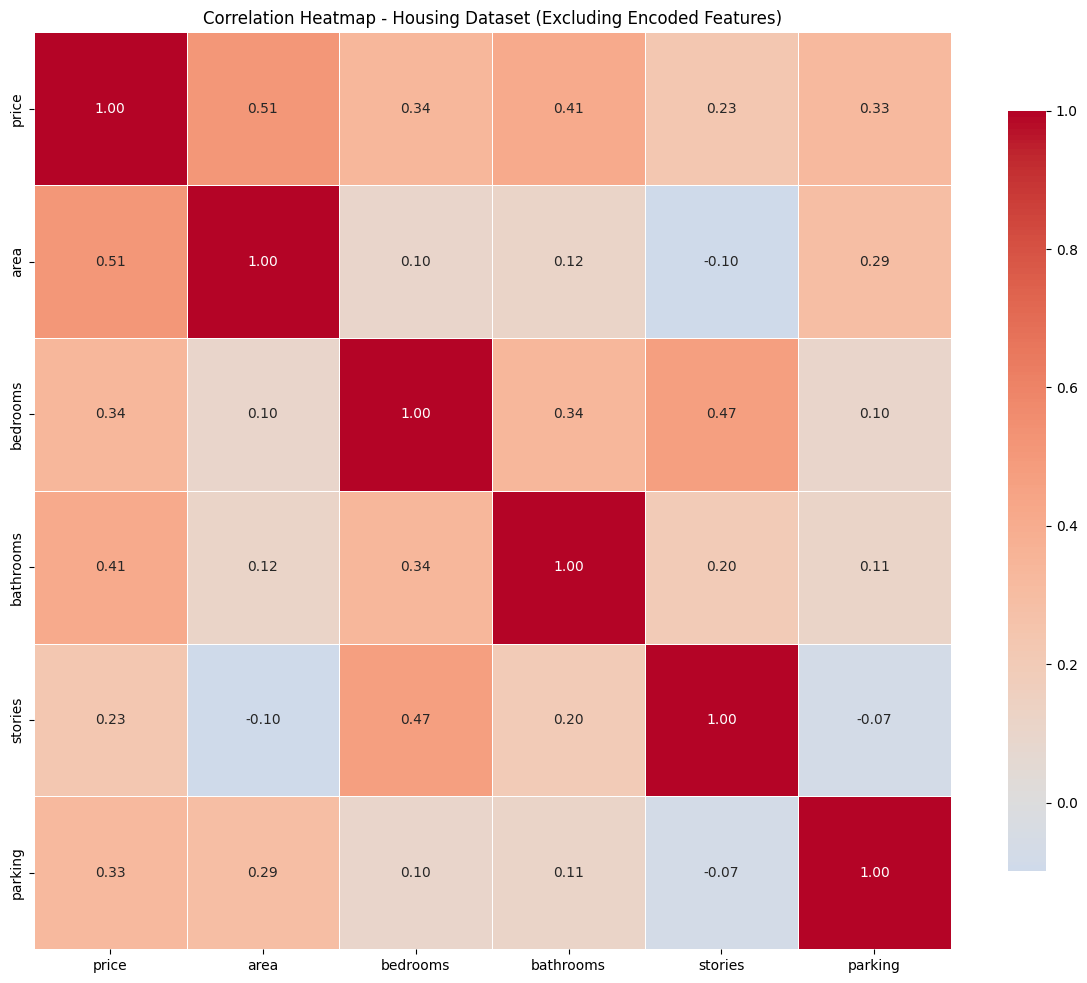

In [17]:
# Create correlation heatmap excluding label-encoded features
plt.figure(figsize=(12, 10))
numeric_data = dataset.select_dtypes(include=[np.number])
# Exclude label-encoded columns (those ending with "_code")
numeric_data = numeric_data[[col for col in numeric_data.columns if not col.endswith("_code")]]
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Housing Dataset (Excluding Encoded Features)')
plt.tight_layout()
plt.show()

In [20]:
# Standardize the area feature before training
area_scaler = StandardScaler()
dataset['area_scaled'] = area_scaler.fit_transform(dataset[['area']])

feature_list = [
    'area_scaled', 'bedrooms', 'bathrooms', 'stories', 'parking',
    'mainroad_code', 'guestroom_code', 'basement_code',
    'hotwaterheating_code', 'airconditioning_code',
    'prefarea_code', 'furnishingstatus_code'
]

X = dataset[feature_list]
print(f'Features shape: {X.shape}')

y = dataset['price']
print(f'Target shape: {y.shape}')

dataset.head()

Features shape: (463, 12)
Target shape: (463,)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,...,prefarea,furnishingstatus,mainroad_code,guestroom_code,basement_code,hotwaterheating_code,airconditioning_code,prefarea_code,furnishingstatus_code,area_scaled
0,9100000,6000,4,1,2,yes,no,yes,no,no,...,no,semi-furnished,1,0,1,0,0,0,1,0.687763
1,9100000,6600,4,2,2,yes,yes,yes,no,yes,...,yes,unfurnished,1,1,1,0,1,1,2,1.022328
2,8890000,4600,3,2,2,yes,yes,no,no,yes,...,no,furnished,1,1,0,0,1,0,0,-0.092888
3,8855000,6420,3,2,2,yes,no,no,no,yes,...,yes,semi-furnished,1,0,0,0,1,1,1,0.921958
4,8750000,4320,3,1,2,yes,no,yes,yes,no,...,no,semi-furnished,1,0,1,1,0,0,1,-0.249018


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=None)

print(f'Training features shape: {X_train.shape}')
print(f'Training target shape: {y_train.shape}')
print(f'Test features shape: {X_test.shape}')
print(f'Test target shape: {y_test.shape}')

Training features shape: (370, 12)
Training target shape: (370,)
Test features shape: (93, 12)
Test target shape: (93,)


In [22]:
# Scale the remaining features (area is already standardized)
scaler = StandardScaler()
cols_to_scale = [col for col in X_train.columns if col != 'area_scaled']

# Fit on training data for non-area features
X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform test data using same scaler
X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print('Features scaled using StandardScaler (area standardization was applied separately)')
print(f'\nOriginal X_train first row: {X_train.iloc[0].values}')
print(f'\nScaled X_train first row: {X_train_scaled.iloc[0].values}')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict on the test set
predictions = model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('\nLinear Regression evaluation:')
print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R² score: {r2:.4f}')

coefficients = pd.Series(model.coef_, index=feature_list)

print('\nModel coefficients:')
print(f'Intercept: {model.intercept_:.2f}')
print(coefficients)

Features scaled using StandardScaler (area standardization was applied separately)

Original X_train first row: [-0.44975707  3.          1.          1.          0.          1.
  0.          0.          0.          0.          0.          0.        ]

Scaled X_train first row: [-0.44975707  0.21459772 -0.50448858 -0.972637   -0.72205424  0.43115825
 -0.47878584 -0.78467861 -0.19082601 -0.58359208 -0.53777189 -1.48624884]

Linear Regression evaluation:
Mean Squared Error: 1034207650903.92
Root Mean Squared Error: 1016960.00
Mean Absolute Error: 758775.44
R² score: 0.6028

Model coefficients:
Intercept: 4360539.90
area_scaled              425999.728093
bedrooms                  44349.060032
bathrooms                362543.328627
stories                  193908.534855
parking                  182633.588980
mainroad_code            134498.436105
guestroom_code           159900.242790
basement_code            137710.599533
hotwaterheating_code     172823.357527
airconditioning_code     3295

Predicted price for the new house: 4622742.12


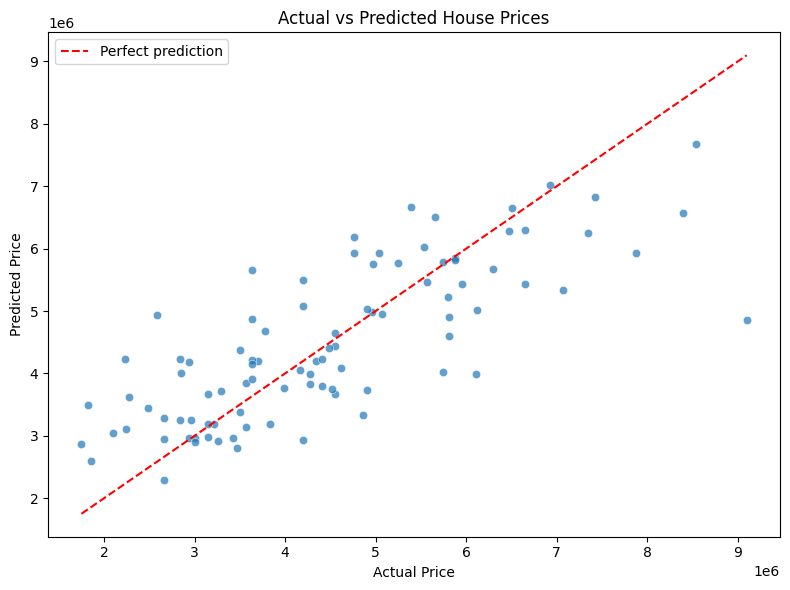

In [23]:
# Predict the price for a new house record
# new_house values must follow the feature_list order:
# ['area_scaled', 'bedrooms', 'bathrooms', 'stories', 'parking',
#  'mainroad_code', 'guestroom_code', 'basement_code',
#  'hotwaterheating_code', 'airconditioning_code',
#  'prefarea_code', 'furnishingstatus_code']

raw_new_house = {
    'area': 6000,
    'bedrooms': 4,
    'bathrooms': 1,
    'stories': 2,
    'parking': 1,
    'mainroad_code': 1,
    'guestroom_code': 0,
    'basement_code': 1,
    'hotwaterheating_code': 0,
    'airconditioning_code': 0,
    'prefarea_code': 0,
    'furnishingstatus_code': 1
}

new_house_df = pd.DataFrame([raw_new_house])
new_house_df['area_scaled'] = area_scaler.transform(new_house_df[['area']])
new_house_df = new_house_df[feature_list]

new_house_scaled = new_house_df.copy()
new_house_scaled[cols_to_scale] = scaler.transform(new_house_df[cols_to_scale])

predicted_price = model.predict(new_house_scaled)[0]
print(f'Predicted price for the new house: {predicted_price:.2f}')

# Plot actual vs predicted prices for the test set
results_df = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': predictions
})

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual', y='Predicted', data=results_df, alpha=0.7)
plt.plot([results_df['Actual'].min(), results_df['Actual'].max()],
         [results_df['Actual'].min(), results_df['Actual'].max()],
         color='red', linestyle='--', label='Perfect prediction')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

Random Forest evaluation:
Mean Squared Error:       1061018096338.03
Root Mean Squared Error:  1030057.33
Mean Absolute Error:      764529.74
R² score:                  0.5925


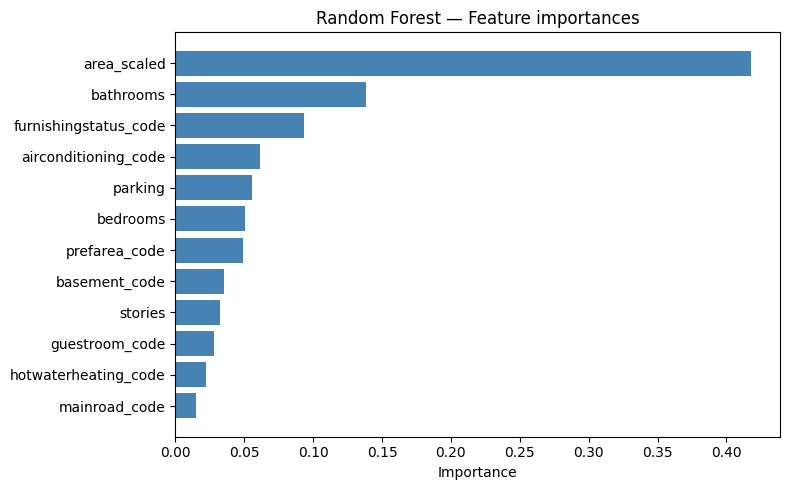

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Random Forest does not require feature scaling, so we use unscaled data
# Create and train the Random Forest model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Predict on the test set
predictions = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('Random Forest evaluation:')
print(f'Mean Squared Error:       {mse:.2f}')
print(f'Root Mean Squared Error:  {rmse:.2f}')
print(f'Mean Absolute Error:      {mae:.2f}')
print(f'R² score:                  {r2:.4f}')

# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_list,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest — Feature importances')
plt.tight_layout()
plt.show()


Predicted price for the new house: 4963980.00


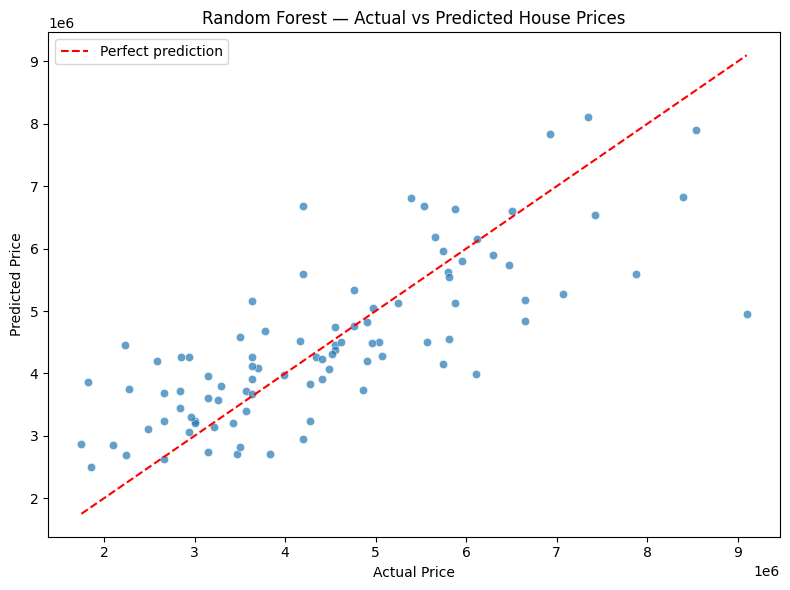

In [25]:
# Predict the price for a new house record
# new_house values must follow the feature_list order:
# ['area_scaled', 'bedrooms', 'bathrooms', 'stories', 'parking',
#  'mainroad_code', 'guestroom_code', 'basement_code',
#  'hotwaterheating_code', 'airconditioning_code',
#  'prefarea_code', 'furnishingstatus_code']

raw_new_house = {
    'area': 6000,
    'bedrooms': 4,
    'bathrooms': 1,
    'stories': 2,
    'parking': 1,
    'mainroad_code': 1,
    'guestroom_code': 0,
    'basement_code': 1,
    'hotwaterheating_code': 0,
    'airconditioning_code': 0,
    'prefarea_code': 0,
    'furnishingstatus_code': 1
}

new_house_df = pd.DataFrame([raw_new_house])
new_house_df['area_scaled'] = area_scaler.transform(new_house_df[['area']])
new_house_df = new_house_df[feature_list]

# Random Forest does not require scaling
predicted_price = model.predict(new_house_df)[0]
print(f'Predicted price for the new house: {predicted_price:.2f}')

# Plot actual vs predicted prices for the test set
results_df = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': predictions
})

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual', y='Predicted', data=results_df, alpha=0.7)
plt.plot([results_df['Actual'].min(), results_df['Actual'].max()],
         [results_df['Actual'].min(), results_df['Actual'].max()],
         color='red', linestyle='--', label='Perfect prediction')
plt.title('Random Forest — Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()
